In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

NAV: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [4]:
print("NAV Columns:")
print(nav.columns)

print("\nPerformance Columns:")
print(performance.columns)

print("\nBenchmark Columns:")
print(benchmark.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Benchmark Columns:
Index(['date', 'index_name', 'close_value'], dtype='object')


# Task 1: Daily Return Calculation

Daily Return = (Today's NAV / Previous Day's NAV) − 1

In [5]:
# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Display first few rows
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


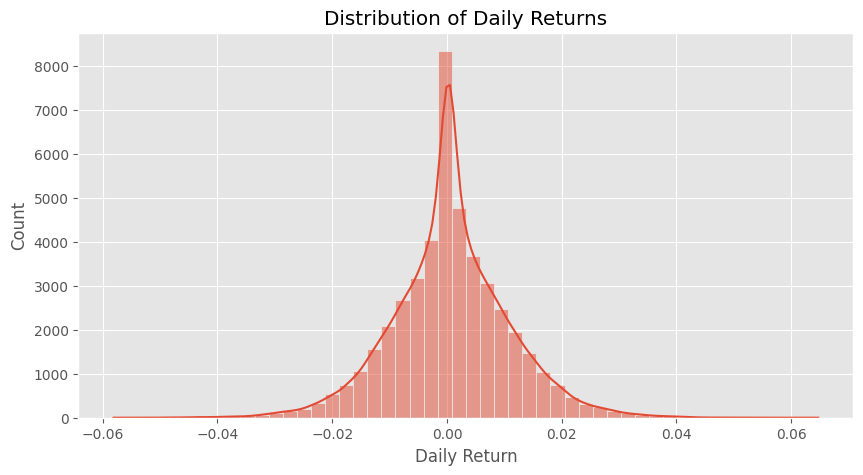

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")

plt.show()

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# Task 2: CAGR Calculation (1 Year, 3 Year, 5 Year)

In [8]:
# Calculate CAGR for each fund

cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

# Convert percentage returns to CAGR values
cagr_table["CAGR_1Y"] = cagr_table["return_1yr_pct"] / 100

cagr_table["CAGR_3Y"] = (
    (1 + cagr_table["return_3yr_pct"] / 100) ** (1/3) - 1
)

cagr_table["CAGR_5Y"] = (
    (1 + cagr_table["return_5yr_pct"] / 100) ** (1/5) - 1
)

cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45,0.1242,0.039610,0.027361
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23,0.1525,0.036331,0.026966
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,0.2456,0.072572,0.038293
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,0.2059,0.071848,0.040264
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43,0.0534,0.019837,0.010632


In [9]:
cagr_table.to_csv("cagr_table.csv", index=False)

print("CAGR Table Saved Successfully!")

CAGR Table Saved Successfully!


# Task 3: Sharpe Ratio

In [10]:
# Risk-free rate (RBI Repo Rate Proxy)
risk_free_rate = 0.065

# Calculate annualized Sharpe Ratio
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["Sharpe_Ratio"] = (
    (sharpe["mean"] * 252 - risk_free_rate)
    /
    (sharpe["std"] * np.sqrt(252))
)

# Highest Sharpe first
sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head()

,amfi_code,mean,std,Sharpe_Ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101


In [11]:
sharpe.to_csv("sharpe_ratio.csv", index=False)

print("Sharpe Ratio Saved Successfully!")

Sharpe Ratio Saved Successfully!


# Task 4: Sortino Ratio

In [12]:
# Downside returns
downside = nav.copy()

downside["downside_return"] = downside["daily_return"].where(
    downside["daily_return"] < 0,
    0
)

sortino = (
    downside.groupby("amfi_code")
    .agg(
        mean_return=("daily_return", "mean"),
        downside_std=("downside_return", "std")
    )
    .reset_index()
)

sortino["Sortino_Ratio"] = (
    (sortino["mean_return"] * 252 - risk_free_rate)
    /
    (sortino["downside_std"] * np.sqrt(252))
)

sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino.head()

,amfi_code,mean_return,downside_std,Sortino_Ratio
34,148567,0.001074,0.004960,2.610563
30,120843,0.001082,0.005306,2.464498
36,148569,0.001124,0.006034,2.278681
19,119551,0.000917,0.004661,2.243897
25,120505,0.001161,0.006643,2.158934


In [13]:
sortino.to_csv("sortino_ratio.csv", index=False)

print("Sortino Ratio Saved Successfully!")

Sortino Ratio Saved Successfully!


# Task 5: Alpha and Beta Calculation

In [14]:
# Prepare benchmark data
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Use Nifty 100 benchmark only
nifty100 = benchmark[
    benchmark["index_name"].str.contains("100", case=False, na=False)
].copy()

# Calculate benchmark daily returns
nifty100 = nifty100.sort_values("date")
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

alpha_beta = []

# Calculate Alpha & Beta for each fund
for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append({
            "amfi_code": code,
            "Alpha": intercept * 252,
            "Beta": slope
        })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
alpha_beta.to_csv("alpha_beta.csv", index=False)

print("Alpha Beta CSV Saved!")

Alpha Beta CSV Saved!


# Task 6: Maximum Drawdown

In [16]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].copy()

    fund = fund.sort_values("date")

    fund["Running_Max"] = fund["nav"].cummax()

    fund["Drawdown"] = (
        fund["nav"] /
        fund["Running_Max"]
        - 1
    )

    drawdown_list.append({

        "amfi_code": code,

        "Max_Drawdown": fund["Drawdown"].min()

    })

drawdown = pd.DataFrame(drawdown_list)

drawdown.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [17]:
drawdown.to_csv("maximum_drawdown.csv", index=False)

print("Maximum Drawdown Saved!")

Maximum Drawdown Saved!


# Task 7: Fund Scorecard

In [18]:
# Merge performance metrics
scorecard = performance.merge(
    sharpe[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown,
    on="amfi_code",
    how="left"
)

# Ranking
scorecard["Return_Rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(ascending=False)

# Composite Score
scorecard["Fund_Score"] = (
      0.30 * scorecard["Return_Rank"]
    + 0.25 * scorecard["Sharpe_Rank"]
    + 0.20 * scorecard["Alpha_Rank"]
    + 0.15 * scorecard["Expense_Rank"]
    + 0.10 * scorecard["Drawdown_Rank"]
)

# Convert to 0–100 scale
scorecard["Fund_Score"] = (
    100 * (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"]
    ) /
    (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"].min()
    )
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.180101,0.292636,0.000549,-0.181885,8.0,5.0,3.0,15.0,25.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.306744,0.273305,-0.022830,-0.129740,11.0,2.0,5.0,22.0,13.0,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,1.093699,0.271954,0.005104,-0.162172,10.0,7.0,6.0,17.0,20.0,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.945308,0.303370,-0.023196,-0.287060,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.448291,0.269838,0.023684,-0.112657,17.0,1.0,7.0,23.0,8.0,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,0.949796,0.300579,0.011455,-0.311719,6.0,13.0,2.0,26.5,37.0,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,1.132122,0.265986,-0.002523,-0.172481,9.0,6.0,8.0,38.0,22.0,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,1.026524,0.211948,0.016232,-0.125883,20.0,10.0,13.0,12.0,12.0,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,0.998231,0.260767,-0.066265,-0.209609,15.0,11.0,9.0,17.0,28.0,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,1.234930,0.282704,0.018134,-0.163967,23.0,3.0,4.0,36.5,21.0,67.401392


In [19]:
scorecard.to_csv("fund_scorecard.csv", index=False)

print("Fund Scorecard Saved Successfully!")

Fund Scorecard Saved Successfully!


# Task 8: Benchmark Comparison

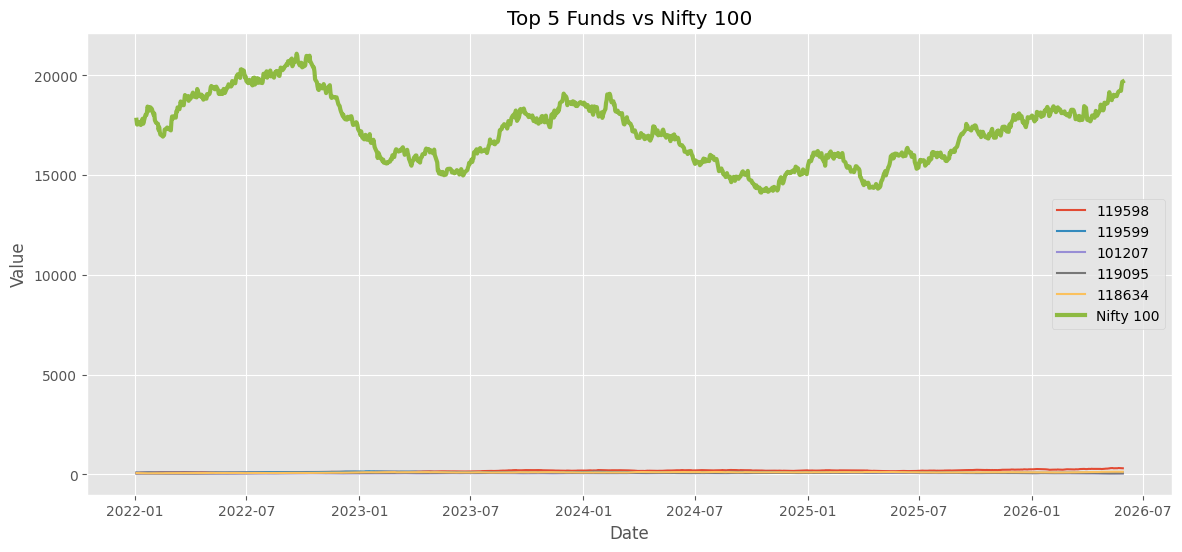

In [20]:
# Top 5 funds by 3-year return
top5 = performance.nlargest(5, "return_3yr_pct")["amfi_code"]

plt.figure(figsize=(14,6))

for code in top5:

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

# Plot Nifty 100
nifty100 = benchmark[
    benchmark["index_name"].str.contains("100", case=False, na=False)
]

plt.plot(
    pd.to_datetime(nifty100["date"]),
    nifty100["close_value"],
    linewidth=3,
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 100")

plt.xlabel("Date")

plt.ylabel("Value")

plt.legend()

plt.show()

In [21]:
plt.figure(figsize=(14,6))

for code in top5:
    fund = nav[nav["amfi_code"] == code]
    plt.plot(fund["date"], fund["nav"], label=str(code))

plt.plot(
    pd.to_datetime(nifty100["date"]),
    nifty100["close_value"],
    linewidth=3,
    label="Nifty 100"
)

plt.title("Top 5 Funds vs Nifty 100")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Benchmark Comparison PNG Saved!")

Benchmark Comparison PNG Saved!
